# FIN6131 Assignment 1 — Mean–Variance Portfolio Selection
**Nine diversified ETFs · five years · unrestricted versus long-only investing**

This notebook implements the complete analysis in the accompanying three-page
LaTeX report. **Run All** uses a frozen Yahoo Finance adjusted-close snapshot
and needs no network or companion files. The exact CSV is embedded below for
standalone execution; the repository also archives the provider's raw JSON.

- Analysis window: **2021-09-19 ≤ return date < 2026-09-19**.
- Training: dates before **2024-09-19**; test: dates on/after that boundary.
- First price is the prior trading close (2021-09-17), used only to calculate
  the first in-window return. No missing prices are filled.
- 252 sessions per year; annual risk-free rate **3%**; reproducibility seed **6131**.
- Full-sample estimates are descriptive, **not** the weights used in the backtest.

**Return convention.** The assignment requests annualized log-return moments.
We therefore optimize with $\mu=252\bar r$ and $\Sigma=252\widehat{\mathrm{Cov}}(r)$,
using $(w^\top\mu-0.03)/\sqrt{w^\top\Sigma w}$ as its conventional Sharpe objective.
Weighted asset log returns are only a first-order approximation to portfolio
returns, especially under leverage. Realized out-of-sample wealth instead uses
exact weighted **simple** returns. The CAL below is a line in this approximate
mean–variance coordinate system, not an exact log-growth identity.

In [1]:
from pathlib import Path
import base64, gzip, hashlib, io, json, sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
from scipy.optimize import minimize

SEED = 6131
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
RF, PERIODS = 0.03, 252
START, SPLIT, END = pd.Timestamp('2021-09-19'), pd.Timestamp('2024-09-19'), pd.Timestamp('2026-09-19')
TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'LQD', 'GLD', 'VNQ']
REFRESH = False  # Explicit opt-in; provider revisions may change all conclusions.
ROOT = Path.cwd()
if (ROOT / 'assignment1' / 'data').exists():
    ROOT = ROOT / 'assignment1'
OUT = ROOT / ('outputs_refresh' if REFRESH else 'outputs')
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'savefig.bbox': 'tight'})
print('Interpreter:', sys.executable)
print('Python:', platform.python_version(), '| NumPy:', np.__version__, '| pandas:', pd.__version__)

Interpreter: /home/weiqi/Desktop/CUHKSZ/FIN6131-Portf-and-Asset-Mngt/.venv/bin/python
Python: 3.11.16 | NumPy: 2.4.6 | pandas: 3.0.6


## 1. Download, provenance, and data validation

The initial `yfinance.download` call was blocked from this machine. The same
provider's public chart endpoint was retrieved in a real browser on September
19, 2026, preserving its `adjclose` field. Every raw response has a recorded URL,
retrieval timestamp, and SHA-256 in `data/metadata.json`. Yahoo adjusted closes
account for splits and distributions [3]; they are a historical total-return proxy,
not raw tradable execution prices.

The cell below offers a **real yfinance refresh** (`auto_adjust=False`, selecting
`Adj Close` explicitly). Default execution validates the local CSV or uses the
byte-identical embedded snapshot. Refresh results go into `outputs_refresh/`;
they do not silently replace the report's data or results. Network errors stop
refresh instead of silently substituting another sample.

In [2]:
# Exact archived CSV, compressed only to keep the standalone notebook small.
SNAPSHOT_SHA256 = '8baf117bd68b1703cd1c71c7884f3111fe697409cf628f78a18176c3a54651cc'
SNAPSHOT_GZIP_BASE64 = '...'

if REFRESH:
    import yfinance as yf
    fetched = yf.download(TICKERS, start='2021-09-17', end='2026-09-19',
                          interval='1d', auto_adjust=False, back_adjust=False,
                          repair=False, progress=False, threads=False)
    if fetched is None or fetched.empty or 'Adj Close' not in fetched.columns.get_level_values(0):
        raise RuntimeError('Yahoo download failed: keep REFRESH=False for the verified snapshot.')
    prices = fetched['Adj Close'].reindex(columns=TICKERS)
    prices.index = pd.DatetimeIndex(prices.index).tz_localize(None).normalize()
    print('REFRESHED DATA — differs potentially from the submitted report.')
else:
    local = ROOT / 'data/adjusted_close.csv'
    csv_bytes = local.read_bytes() if local.exists() else gzip.decompress(base64.b64decode(SNAPSHOT_GZIP_BASE64))
    assert hashlib.sha256(csv_bytes).hexdigest() == SNAPSHOT_SHA256, 'Snapshot checksum mismatch'
    prices = pd.read_csv(io.BytesIO(csv_bytes), index_col='Date', parse_dates=True, float_precision='round_trip')
    print('Verified CSV SHA-256:', SNAPSHOT_SHA256)

assert list(prices.columns) == TICKERS
assert isinstance(prices.index, pd.DatetimeIndex)
assert prices.index.is_monotonic_increasing and not prices.index.has_duplicates
assert np.isfinite(prices.to_numpy()).all() and (prices.to_numpy() > 0).all()
assert prices.index[0] == pd.Timestamp('2021-09-17') and prices.index[-1] == pd.Timestamp('2026-09-18')
assert len(prices) > 1200, 'Insufficient five-year history'
print(f'{len(prices)} complete prices per ETF; {int(prices.isna().sum().sum())} missing observations')
display(prices.iloc[[0, -1]].round(3))

Verified CSV SHA-256: 8baf117bd68b1703cd1c71c7884f3111fe697409cf628f78a18176c3a54651cc
1256 complete prices per ETF; 0 missing observations


,SPY,QQQ,IWM,EFA,EEM,TLT,LQD,GLD,VNQ
Date,,,,,,,,,
2021-09-17,412.843,362.798,208.511,68.77,45.673,125.05,110.823,163.77,87.798
2026-09-18,761.690,721.450,284.100,104.97,67.030,81.25,104.700,401.17,92.910


## 2. Estimation and numerical methods

For each asset, $r_{i,t}=\log(P_{i,t}/P_{i,t-1})$. The sample covariance uses
$T-1$ in its denominator. The covariance must be positive definite; the notebook
does not hide an ill-conditioned problem by silently adding a ridge penalty.

For target return $m$, solve
\[
\min_w\;\tfrac12 w^\top\Sigma w\quad\text{s.t.}\quad
\mathbf1^\top w=1,\quad\mu^\top w=m,
\]
with $w\in\mathbb R^9$ (shorts allowed), or additionally $w_i\ge0$ (long-only).
The **global minimum variance portfolio** drops the target-return constraint.
Only the branch above each regime's MVP is efficient.

Write $A=\mathbf1^\top\Sigma^{-1}\mathbf1$,
$B=\mathbf1^\top\Sigma^{-1}\mu$, $C=\mu^\top\Sigma^{-1}\mu$, and $D=AC-B^2$.
The unrestricted formulas are
\[
w_G=\Sigma^{-1}\mathbf1/A,\quad
w(m)=\Sigma^{-1}\!\left[\frac{C-Bm}{D}\mathbf1+\frac{Am-B}{D}\mu\right],\quad
\sigma^2(m)=\frac{Am^2-2Bm+C}{D}.
\]
We cross-check these results against independent SLSQP minimization.

For the tangency portfolio, maximize $(w^\top\mu-r_f)/\sigma(w)$.
The unrestricted solution is $w_T=\Sigma^{-1}(\mu-r_f\mathbf1)/
[\mathbf1^\top\Sigma^{-1}(\mu-r_f\mathbf1)]$, provided the denominator is positive.
The long-only case uses the globally valid convex transformation
$\min_{z\ge0}z^\top\Sigma z$ subject to $(\mu-r_f\mathbf1)^\top z=1$,
then $w=z/(\mathbf1^\top z)$. This requires a positive attainable excess return.
All solver statuses and constraint residuals are checked.

In [3]:
"""Log-moment MPT estimation and exact simple-return portfolio evaluation.

This module is self-contained so its source can be embedded in the submission
notebook. Annual expected log returns are an MPT approximation, not exact
portfolio growth rates. Optimization subtracts the assignment's annual rf
convention directly; realized performance instead uses exact simple returns.
"""
import numpy as np
import pandas as pd
from scipy.optimize import minimize


def _real_array(value, name):
    array = np.asarray(value)
    if not np.issubdtype(array.dtype, np.number) or np.iscomplexobj(array):
        raise ValueError(f"{name} must contain real numeric values")
    return array.astype(float)


def _scalar(value, name):
    array = _real_array(value, name)
    if array.ndim != 0 or not np.isfinite(array):
        raise ValueError(f"{name} must be a finite real scalar")
    return float(array)


def _periods(periods):
    periods = _scalar(periods, "periods")
    if not np.isfinite(periods) or periods <= 0:
        raise ValueError("periods must be a positive finite number")
    return periods


def _frame(data, name, min_rows):
    if not isinstance(data, pd.DataFrame) or data.shape[1] == 0 or len(data) < min_rows:
        raise ValueError(f"{name} must be a nonempty DataFrame with at least {min_rows} rows")
    if not data.index.is_unique or not data.index.is_monotonic_increasing:
        raise ValueError(f"{name} index must be unique and increasing")
    if not data.columns.is_unique:
        raise ValueError(f"{name} columns must be unique")
    if any(not pd.api.types.is_numeric_dtype(dtype) or
           pd.api.types.is_bool_dtype(dtype) or pd.api.types.is_complex_dtype(dtype)
           for dtype in data.dtypes):
        raise ValueError(f"{name} must contain real numeric values")
    values = data.to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError(f"{name} must be finite and complete; no filling is performed")
    return values


def _moments(mu, cov):
    mu, cov = _real_array(mu, "mu"), _real_array(cov, "cov")
    if mu.ndim != 1 or mu.size == 0 or not np.isfinite(mu).all():
        raise ValueError("mu must be a nonempty finite vector")
    if cov.shape != (mu.size, mu.size) or not np.isfinite(cov).all():
        raise ValueError("cov must be a finite square matrix matching mu")
    if not np.allclose(cov, cov.T, rtol=1e-10, atol=1e-14):
        raise ValueError("cov must be symmetric")
    cov = (cov + cov.T) / 2
    eigenvalues = np.linalg.eigvalsh(cov)
    if eigenvalues[0] <= np.finfo(float).eps * mu.size * max(eigenvalues[-1], 0):
        raise ValueError("cov must be numerically positive definite")
    return mu, cov


def estimate(prices, periods=252):
    """Return daily log returns, annual log means, and sample covariance.

    Reject missing/nonpositive prices, unordered or duplicate observations,
    duplicate assets, and singular sample covariance. Never forward fill.
    """
    periods = _periods(periods)
    values = _frame(prices, "prices", min_rows=3)
    if (values <= 0).any():
        raise ValueError("prices must be strictly positive")
    log_returns = np.log(prices.astype(float)).diff().iloc[1:]
    mu, cov = _moments(log_returns.mean().to_numpy() * periods,
                       log_returns.cov().to_numpy() * periods)
    return log_returns, mu, cov


def _check_weights(weights, n, long_only=False):
    weights = _real_array(weights, "weights")
    if weights.shape != (n,) or not np.isfinite(weights).all():
        raise ValueError("weights must be a finite vector matching the assets")
    if abs(weights.sum() - 1) > 1e-8:
        raise ValueError("weights must sum to one; implicit normalization is forbidden")
    if long_only and weights.min() < -1e-9:
        raise ValueError("long-only weights cannot be negative")
    return weights


def _quadratic_program(cov, basis, rhs, start):
    """Convex nonnegative QP with checked solver status and feasibility."""
    scaled_cov = cov / np.max(np.diag(cov))
    result = minimize(lambda w: w @ scaled_cov @ w, start,
                      jac=lambda w: 2 * scaled_cov @ w,
                      method="SLSQP", bounds=[(0., None)] * len(start),
                      constraints={"type": "eq", "fun": lambda w: basis.T @ w - rhs,
                                   "jac": lambda w: basis.T},
                      options={"ftol": 1e-13, "maxiter": 2000})
    weights = np.asarray(result.x, dtype=float)
    if (not result.success or weights.shape != start.shape or
            not np.isfinite(weights).all() or weights.min() < -1e-9 or
            np.max(np.abs(basis.T @ weights - rhs)) > 1e-8):
        raise RuntimeError(f"optimization failed or infeasible: {result.message}")
    return weights


def min_variance(mu, cov, long_only=False, target=None):
    """Fully invested minimum variance weights, optionally at target log return.

    Short-allowed solutions use equality-constrained linear algebra. A target
    selects either branch of the minimum-variance locus (frontier selects the
    efficient upper branch separately).
    """
    mu, cov = _moments(mu, cov)
    if target is not None:
        target = float(target)
        if not np.isfinite(target):
            raise ValueError("target must be finite")
        if np.ptp(mu) == 0:
            if abs(target - mu[0]) > 1e-12:
                raise ValueError("target is infeasible when all means are equal")
            target = None
    ones = np.ones(mu.size)
    basis, rhs = ones[:, None], np.array([1.])
    if target is not None:
        # Centering/scaling prevents avoidable cancellation in the 2x2 solve.
        center, scale = mu.mean(), np.ptp(mu)
        basis = np.column_stack([ones, (mu - center) / scale])
        rhs = np.array([1., (target - center) / scale])
    if long_only:
        start = ones / mu.size
        if target is not None:
            lo, hi = int(np.argmin(mu)), int(np.argmax(mu))
            if target < mu[lo] or target > mu[hi]:
                raise ValueError("target is outside the long-only feasible return range")
            if target == mu[lo] or target == mu[hi]:
                # At endpoints, optimize among all assets tied at that return.
                eligible = mu == target
                weights = np.zeros(mu.size)
                weights[eligible] = min_variance(mu[eligible], cov[np.ix_(eligible, eligible)], True)
                return weights
            fraction = (target - mu[lo]) / (mu[hi] - mu[lo])
            start = np.zeros(mu.size)
            start[lo], start[hi] = 1 - fraction, fraction
        weights = _quadratic_program(cov, basis, rhs, start)
    else:
        solved = np.linalg.solve(cov, basis)
        weights = solved @ np.linalg.solve(basis.T @ solved, rhs)
    _check_weights(weights, mu.size, long_only)
    if target is not None and abs(weights @ mu - target) > 1e-8:
        raise RuntimeError("minimum-variance target constraint was not satisfied")
    return weights


def _risk_free(rf):
    rf = _scalar(rf, "rf")
    if not np.isfinite(rf) or rf <= -1:
        raise ValueError("rf must be finite and greater than -1")
    return rf


def tangency(mu, cov, rf=.03, long_only=False):
    """Maximum positive-excess MPT Sharpe weights at annual risk-free rate rf.

    For shorts, reject nonpositive normalization: no finite conventional
    positive-excess tangency portfolio exists. For long-only weights, solve
    the convex transformed problem min z'cov z subject to (mu-rf)'z=1, z>=0,
    then normalize z to unit budget. No nonconvex ratio optimization is used.
    """
    mu, cov = _moments(mu, cov)
    excess = mu - _risk_free(rf)
    if long_only:
        best = int(np.argmax(excess))
        if excess[best] <= 0:
            raise ValueError("no long-only portfolio has positive excess return")
        # Scale z by max(excess) to keep the equivalent equality well-scaled.
        # If y solves this QP, z=y/max(excess) satisfies excess'z=1.
        scaled_excess = excess / excess[best]
        start = np.zeros(mu.size)
        start[best] = 1.
        direction = _quadratic_program(cov, scaled_excess[:, None], np.array([1.]), start)
    else:
        direction = np.linalg.solve(cov, excess)
        denominator = direction.sum()
        tolerance = np.finfo(float).eps * mu.size * np.abs(direction).sum()
        if denominator <= tolerance:
            raise ValueError("no finite conventional positive-excess tangency: nonpositive normalization")
    weights = direction / direction.sum()
    _check_weights(weights, mu.size, long_only)
    if weights @ excess <= 0:
        raise RuntimeError("optimization did not produce positive excess return")
    return weights


def portfolio_stats(weights, mu, cov, rf=.03):
    """Annual log-moment MPT statistics; not exact realized growth statistics."""
    mu, cov = _moments(mu, cov)
    weights = _check_weights(weights, mu.size)
    rf = _risk_free(rf)
    mean = float(weights @ mu)
    volatility = float(np.sqrt(weights @ cov @ weights))
    return {"return": mean, "volatility": volatility,
            "sharpe": (mean - rf) / volatility,
            "gross_exposure": float(np.abs(weights).sum())}


def frontier(mu, cov, long_only=False, points=100, max_return=None):
    """Upper efficient branch as a DataFrame with return/volatility columns.

    Begin at the global MVP and end at max_return (default: the larger of
    the highest asset mean and MVP mean). Short-allowed frontiers are unbounded;
    max_return selects a plotting range, not an economic upper bound. Identical
    asset means yield repeated copies of the sole efficient location.
    """
    mu, cov = _moments(mu, cov)
    if isinstance(points, (bool, np.bool_)) or not isinstance(points, (int, np.integer)) or points < 2:
        raise ValueError("points must be an integer at least 2")
    mvp = min_variance(mu, cov, long_only)
    start = float(mvp @ mu)
    stop = max(start, float(mu.max())) if max_return is None else float(max_return)
    if not np.isfinite(stop) or stop < start - 1e-12:
        raise ValueError("max_return must be finite and not below the MVP return")
    if long_only and stop > mu.max() + 1e-12:
        raise ValueError("max_return exceeds the long-only feasible return range")
    if long_only:
        start, stop = np.clip([start, stop], mu.min(), mu.max())
    targets = np.linspace(start, stop, points)
    risks = []
    for i, target in enumerate(targets):
        w = mvp if i == 0 else min_variance(mu, cov, long_only, target)
        risks.append(float(np.sqrt(w @ cov @ w)))
    return pd.DataFrame({"return": targets, "volatility": risks})


def backtest(log_returns, weights, rf=.03, periods=252):
    """Evaluate frozen target weights rebalanced daily, with no trading costs.

    The caller supplies out-of-sample asset log returns in the SAME asset order
    as the training weights, including the first test day's return relative to
    the last training close. This function never estimates or changes weights.
    Daily portfolio simple return is expm1(asset log returns) @ weights, NOT
    expm1(weighted asset log returns). Borrow/short costs are not modeled.

    annual_return is arithmetic daily mean times periods; volatility uses ddof=1;
    Sharpe annualizes daily excess over (1+rf)**(1/periods)-1. CAGR compounds exact
    daily returns. max_drawdown is nonpositive and includes initial wealth=1.
    Zero volatility gives NaN Sharpe. Nonpositive wealth raises ValueError.
    """
    periods, rf = _periods(periods), _risk_free(rf)
    values = _frame(log_returns, "log_returns", min_rows=2)
    weights = _check_weights(weights, values.shape[1])
    with np.errstate(over="ignore", invalid="ignore"):
        daily = np.expm1(values) @ weights
    if not np.isfinite(daily).all():
        raise ValueError("portfolio simple returns must remain finite")
    if (daily <= -1).any():
        raise ValueError("portfolio is bankrupt: a daily return is at or below -100%")
    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        wealth = np.r_[1., np.cumprod(1 + daily)]
        cagr = float(np.expm1(np.log1p(daily).mean() * periods))
    if not np.isfinite(wealth).all() or not np.isfinite(cagr):
        raise ValueError("wealth and CAGR must remain finite")
    if (wealth <= 0).any():
        raise ValueError("portfolio is bankrupt or wealth underflowed to zero")
    volatility = float(daily.std(ddof=1) * np.sqrt(periods))
    mean = float(daily.mean())
    rf_daily = float(np.expm1(np.log1p(rf) / periods))
    metrics = {"annual_return": mean * periods, "volatility": volatility,
               "sharpe": (mean - rf_daily) * periods / volatility if volatility > 0 else float("nan"),
               "cagr": cagr, "total_return": float(wealth[-1] - 1),
               "max_drawdown": float(np.min(wealth / np.maximum.accumulate(wealth) - 1))}
    return pd.Series(daily, index=log_returns.index, name="portfolio_return"), metrics

In [4]:
log_returns, mu, cov = estimate(prices)
log_returns = log_returns.loc[(log_returns.index >= START) & (log_returns.index < END)]
# Explicitly recompute moments on the analysis window, not the extra prior close.
mu = PERIODS * log_returns.mean().to_numpy()
cov = PERIODS * log_returns.cov().to_numpy()
train = log_returns.loc[log_returns.index < SPLIT]
test = log_returns.loc[log_returns.index >= SPLIT]
assert len(train) + len(test) == len(log_returns)
assert train.index.max() < test.index.min()
mu_is, cov_is = PERIODS * train.mean().to_numpy(), PERIODS * train.cov().to_numpy()
asset_stats = pd.DataFrame({'Asset class': ['US large-cap', 'Nasdaq-100', 'US small-cap',
    'Developed ex-US equity', 'Emerging equity', 'Long US Treasuries',
    'Investment-grade credit', 'Gold', 'US REITs'],
    'Annual log mean': mu, 'Annual volatility': np.sqrt(np.diag(cov))}, index=TICKERS)
asset_stats['Sharpe proxy'] = (asset_stats['Annual log mean'] - RF) / asset_stats['Annual volatility']
display(asset_stats.round(4))
display(pd.DataFrame(cov, index=TICKERS, columns=TICKERS).round(6))
print(f'Return observations: full={len(log_returns)}, training={len(train)}, test={len(test)}')
print('Covariance condition number:', np.linalg.cond(cov))
asset_stats.to_csv(OUT / 'asset_statistics.csv')
pd.DataFrame(cov, index=TICKERS, columns=TICKERS).to_csv(OUT / 'annual_covariance.csv')
log_returns.to_csv(OUT / 'daily_log_returns.csv')

,Asset class,Annual log mean,Annual volatility,Sharpe proxy
SPY,US large-cap,0.1230,0.1718,0.5413
QQQ,Nasdaq-100,0.1380,0.2297,0.4703
IWM,US small-cap,0.0621,0.2241,0.1433
EFA,Developed ex-US equity,0.0849,0.1662,0.3305
EEM,Emerging equity,0.0770,0.1994,0.2359
TLT,Long US Treasuries,-0.0866,0.1572,-0.7417
LQD,Investment-grade credit,-0.0114,0.0866,-0.4784
GLD,Gold,0.1799,0.1888,0.7940
VNQ,US REITs,0.0114,0.1887,-0.0988


,SPY,QQQ,IWM,EFA,EEM,TLT,LQD,GLD,VNQ
SPY,0.029505,0.037480,0.032782,0.022840,0.023176,0.002397,0.005637,0.004872,0.021281
QQQ,0.037480,0.052762,0.040105,0.028003,0.031736,0.002896,0.007005,0.006460,0.022388
IWM,0.032782,0.040105,0.050226,0.028104,0.029083,0.004187,0.007452,0.007157,0.029675
EFA,0.022840,0.028003,0.028104,0.027616,0.026296,0.004026,0.006077,0.010116,0.019491
EEM,0.023176,0.031736,0.029083,0.026296,0.039754,0.003250,0.005489,0.013328,0.015791
TLT,0.002397,0.002896,0.004187,0.004026,0.003250,0.024707,0.011961,0.006263,0.008686
LQD,0.005637,0.007005,0.007452,0.006077,0.005489,0.011961,0.007494,0.004443,0.007990
GLD,0.004872,0.006460,0.007157,0.010116,0.013328,0.006263,0.004443,0.035641,0.005828
VNQ,0.021281,0.022388,0.029675,0.019491,0.015791,0.008686,0.007990,0.005828,0.035613


Return observations: full=1255, training=754, test=501
Covariance condition number: 238.69236650235217


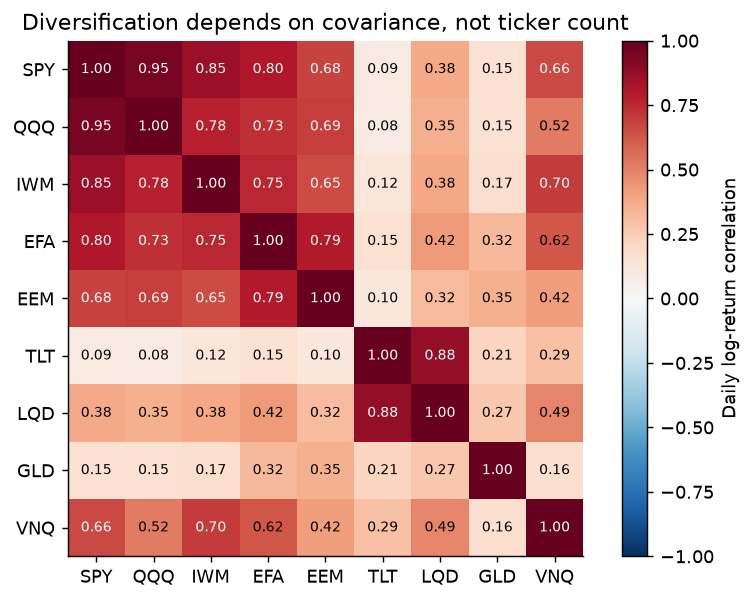

In [5]:
# Dependence, rather than a count of tickers, determines diversification.
fig, ax = plt.subplots(figsize=(7.2, 4.5), layout='constrained')
corr = log_returns.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(9), TICKERS); ax.set_yticks(range(9), TICKERS)
for i in range(9):
    for j in range(9):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > .65 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label='Daily log-return correlation')
ax.set_title('Diversification depends on covariance, not ticker count')
fig.savefig(FIG / 'correlations.pdf')
plt.show()

## 3. Full-sample optimization

`U` denotes budget-constrained but **unrestricted short selling**; `L` denotes
**long-only** risky-asset weights. “Unconstrained” does not remove the budget
condition. Gross exposure is the sum of absolute weights and can exceed 100%
in regime U. No additional leverage limit or borrowing fee is imposed.

In [6]:
def solve_portfolios(mean, covariance):
    """Solve both objectives under both short-sale regimes."""
    return {'U-MVP': min_variance(mean, covariance),
            'L-MVP': min_variance(mean, covariance, long_only=True),
            'U-TP': tangency(mean, covariance, rf=RF),
            'L-TP': tangency(mean, covariance, rf=RF, long_only=True)}

full_weights = solve_portfolios(mu, cov)
full_stats = pd.DataFrame({name: portfolio_stats(w, mu, cov, RF)
                           for name, w in full_weights.items()}).T
weights_table = pd.DataFrame(full_weights, index=TICKERS)
display((weights_table * 100).round(2).rename_axis('Weight (%)'))
display(full_stats.round(4))
weights_table.to_csv(OUT / 'full_sample_weights.csv')
full_stats.to_csv(OUT / 'full_sample_statistics.csv')

# The unrestricted frontier is unbounded in target return; plot a finite range
# that includes its tangency point. The long-only frontier ends at max(mu).
upper = max(float(mu.max()), float(full_stats.loc['U-TP', 'return'])) * 1.12
front_u = frontier(mu, cov, max_return=upper, points=180)
front_l = frontier(mu, cov, long_only=True, points=140)
front_u.to_csv(OUT / 'frontier_unrestricted.csv', index=False)
front_l.to_csv(OUT / 'frontier_long_only.csv', index=False)

,U-MVP,L-MVP,U-TP,L-TP
Weight (%),,,,
SPY,54.21,6.47,519.43,39.42
QQQ,-35.24,0.00,-159.19,0.00
IWM,-10.47,0.00,-104.04,0.00
EFA,-13.57,0.00,-36.34,0.00
EEM,7.90,0.00,-50.89,0.00
TLT,-56.48,0.00,-135.38,0.00
LQD,157.56,85.06,-7.02,0.00
GLD,4.87,8.48,160.36,60.58
VNQ,-8.78,0.00,-86.92,0.00


,return,volatility,sharpe,gross_exposure
U-MVP,0.0448,0.0631,0.2341,3.4908
L-MVP,0.0135,0.0844,-0.1957,1.0000
U-TP,0.6810,0.4189,1.5539,12.5957
L-TP,0.1575,0.1414,0.9015,1.0000


## 4. Efficient frontiers and capital allocation lines

For risky tangency portfolio $T$, allocation $y\ge0$ to it and $1-y$ to cash gives
$\mu_C=r_f+y(\mu_T-r_f)$ and $\sigma_C=y\sigma_T$, hence
$\mu_C=r_f+S_T\sigma_C$. We show **both** regimes' CALs for comparison.
Solid segments correspond to $0\le y\le1$; dashed extensions assume borrowing
at the same 3% rate. Long-only here restricts the **risky sleeve**, not cash
borrowing. If negative cash holdings were prohibited too, the L-CAL would end
at L-TP. Neither expected return nor a CAL guarantees realized performance.

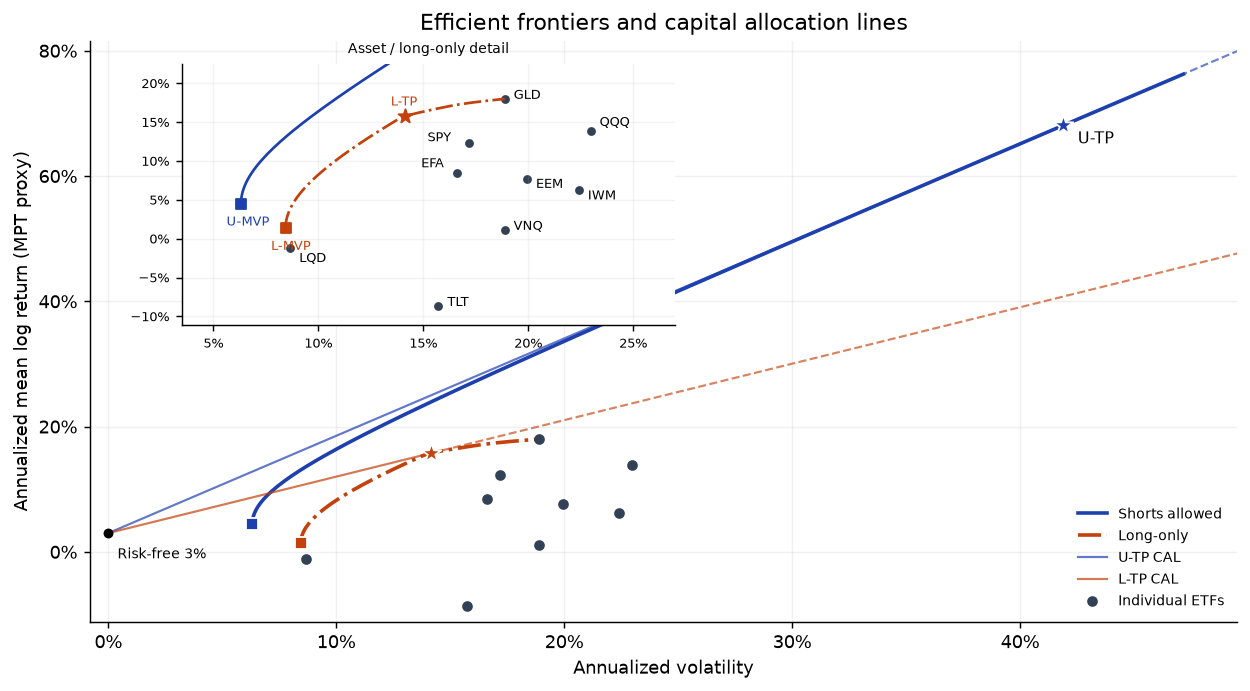

In [7]:
COLORS = {'U-MVP': '#1e40af', 'L-MVP': '#c2410c', 'U-TP': '#1e40af', 'L-TP': '#c2410c'}
fig, ax = plt.subplots(figsize=(9.5, 5.2), layout='constrained')
ax.plot(front_u['volatility'], front_u['return'], color='#1e40af', lw=2, label='Shorts allowed')
ax.plot(front_l['volatility'], front_l['return'], color='#c2410c', lw=2, ls='-.', label='Long-only')
xmax = max(front_u['volatility'].max(), np.sqrt(np.diag(cov)).max()) * 1.05
for name in ['U-TP', 'L-TP']:
    row = full_stats.loc[name]
    xx = np.linspace(0, row['volatility'], 80)
    ax.plot(xx, RF + row['sharpe'] * xx, color=COLORS[name], alpha=.7, lw=1.2, label=name + ' CAL')
    xx = np.linspace(row['volatility'], xmax, 80)
    ax.plot(xx, RF + row['sharpe'] * xx, color=COLORS[name], alpha=.65, lw=1.2, ls='--')
for name, row in full_stats.iterrows():
    ax.scatter(row['volatility'], row['return'], marker='*' if 'TP' in name else 's',
               s=130 if 'TP' in name else 45, color=COLORS[name], edgecolor='white', zorder=5)
    if name == 'U-TP':
        ax.annotate(name, (row['volatility'], row['return']), xytext=(8, -10), textcoords='offset points', fontsize=9)
ax.scatter(np.sqrt(np.diag(cov)), mu, color='#334155', s=24, label='Individual ETFs', zorder=4)
ax.scatter([0], [RF], color='black', s=20, zorder=6)
ax.annotate('Risk-free 3%', (0, RF), xytext=(5, -14), textcoords='offset points', fontsize=8)
ax.set(xlabel='Annualized volatility', ylabel='Annualized mean log return (MPT proxy)',
       title='Efficient frontiers and capital allocation lines', xlim=(-.008, xmax),
       ylim=(min(mu.min() - .025, -.03), upper * 1.07))
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=.18)
ax.legend(loc='lower right', fontsize=8, frameon=False)

# A zoom keeps asset and long-only labels readable despite unrestricted leverage.
zoom = ax.inset_axes([.08, .51, .43, .45])
zoom.plot(front_u['volatility'], front_u['return'], color='#1e40af', lw=1.5)
zoom.plot(front_l['volatility'], front_l['return'], color='#c2410c', lw=1.5, ls='-.')
zoom.scatter(np.sqrt(np.diag(cov)), mu, color='#334155', s=15)
offsets = {'SPY':(-23,1), 'QQQ':(5,3), 'IWM':(5,-5), 'EFA':(-20,3),
           'EEM':(5,-5), 'TLT':(5,0), 'LQD':(5,-8), 'GLD':(5,0), 'VNQ':(5,0)}
for ticker, x, y in zip(TICKERS, np.sqrt(np.diag(cov)), mu):
    zoom.annotate(ticker, (x,y), xytext=offsets[ticker], textcoords='offset points', fontsize=7)
for name in ['U-MVP', 'L-MVP', 'L-TP']:
    row = full_stats.loc[name]
    zoom.scatter(row['volatility'], row['return'], marker='*' if 'TP' in name else 's',
                 s=65 if 'TP' in name else 25, color=COLORS[name], zorder=5)
    zoom.annotate(name, (row['volatility'],row['return']), xytext=(-8, -12 if 'MVP' in name else 6),
                  textcoords='offset points', fontsize=7, color=COLORS[name])
zoom.set(xlim=(.035, .27), ylim=(mu.min()-.025, mu.max()+.045), title='Asset / long-only detail')
zoom.title.set_fontsize(8)
zoom.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); zoom.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
zoom.tick_params(labelsize=7); zoom.grid(alpha=.15)
fig.savefig(FIG / 'frontiers.pdf'); fig.savefig(FIG / 'frontiers.png', dpi=180)
plt.show()

## 5. Three-year training / two-year holdout

Estimate weights **only** from returns dated before 2024-09-19, then freeze those
target weights for the whole holdout. All five strategies rebalance daily to
these targets, including the equal-weight benchmark (each ETF has weight $1/9$).
This is a constant-mix backtest, **not** a buy-and-hold fixed-share backtest.

At each test date, $R_{p,t}=\sum_iw_i[\exp(r_{i,t})-1]$ and
$W_t=\prod_{s\le t}(1+R_{p,s})$. For the first test return the denominator is the
last training close; it is not dropped or used to re-estimate weights.
We report annual arithmetic mean, volatility, excess-return Sharpe, CAGR,
total return, and maximum drawdown. The daily cash rate is
$(1.03)^{1/252}-1$; realized Sharpe is
$\sqrt{252}\,\overline{(R_p-R_{f,d})}/s(R_p)$.
CAGR uses $252/N$ as the annualization exponent. Initial wealth 1 is included
in drawdown peaks so an immediate loss is not missed.

**Frictionless assumptions:** no taxes, turnover costs, bid–ask spreads, margin
calls, stock-loan fees, or differing debit/credit rates. Dividends are represented
through adjusted returns. Short positions earn/pay the same adjusted total
returns symmetrically. This is optimistic, particularly for highly levered U-TP.

,U-MVP,L-MVP,U-TP,L-TP,Equal
Training weight (%),,,,,
SPY,68.92,7.33,560.31,26.58,11.11
QQQ,-41.92,0.00,-159.96,0.00,11.11
IWM,-9.85,0.00,-94.12,0.00,11.11
EFA,-16.79,0.00,-33.99,0.00,11.11
EEM,11.01,3.95,-172.98,0.00,11.11
TLT,-48.33,0.00,-112.78,0.00,11.11
LQD,137.45,67.88,-43.33,0.00,11.11
GLD,11.40,20.84,223.51,73.42,11.11
VNQ,-11.89,0.00,-66.66,0.00,11.11


,return,volatility,sharpe,gross_exposure
U-MVP,0.0507,0.0707,0.2925,3.5755
L-MVP,0.0152,0.0921,-0.1608,1.0000
U-TP,0.8277,0.4389,1.8173,14.6764
L-TP,0.1142,0.1203,0.6997,1.0000


,annual_return,volatility,sharpe,cagr,total_return,max_drawdown
U-MVP,0.0741,0.0552,0.8079,0.0753,0.1553,-0.0593
L-MVP,0.0914,0.0827,0.7472,0.0919,0.1910,-0.0672
U-TP,0.6403,0.5683,1.0747,0.6118,1.5832,-0.6499
L-TP,0.2662,0.1898,1.2471,0.2815,0.6375,-0.1838
Equal,0.1455,0.1255,0.9238,0.1475,0.3147,-0.1148


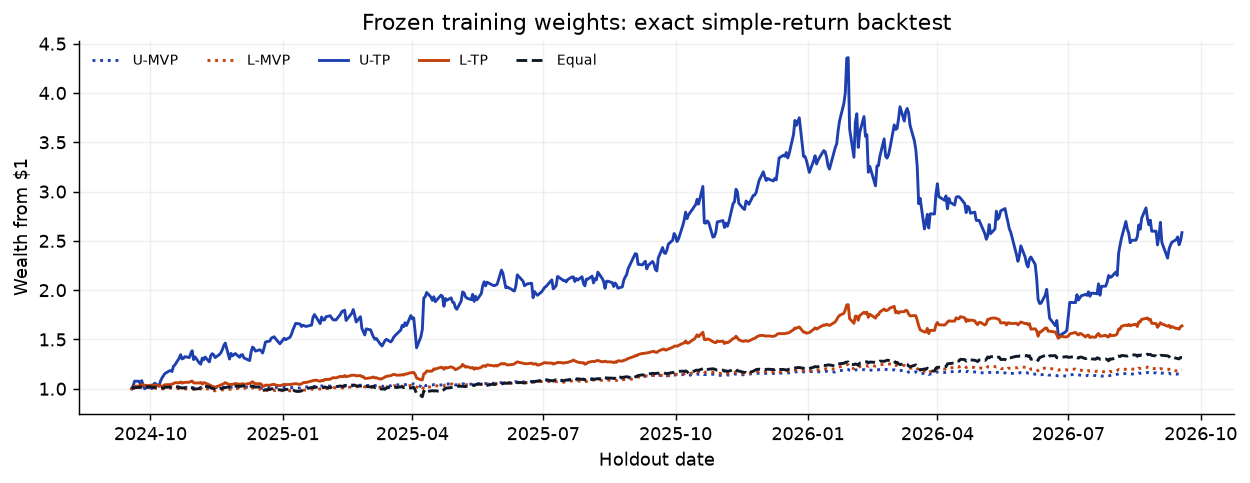

In [8]:
is_weights = solve_portfolios(mu_is, cov_is)
is_stats = pd.DataFrame({name: portfolio_stats(w, mu_is, cov_is, RF)
                         for name, w in is_weights.items()}).T
is_weights['Equal'] = np.ones(len(TICKERS)) / len(TICKERS)
oos_daily, oos_metrics = {}, {}
for name, w in is_weights.items():
    oos_daily[name], oos_metrics[name] = backtest(test, w, rf=RF)
oos = pd.DataFrame(oos_metrics).T
realized = pd.DataFrame(oos_daily)
display((pd.DataFrame(is_weights, index=TICKERS) * 100).round(2).rename_axis('Training weight (%)'))
display(is_stats.round(4))
display(oos.round(4))
pd.DataFrame(is_weights, index=TICKERS).to_csv(OUT / 'in_sample_weights.csv')
is_stats.to_csv(OUT / 'in_sample_statistics.csv')
oos.to_csv(OUT / 'out_of_sample_statistics.csv')
realized.to_csv(OUT / 'out_of_sample_daily_simple_returns.csv')

wealth = (1 + realized).cumprod()
wealth = pd.concat([pd.DataFrame(1., index=[train.index[-1]], columns=wealth.columns), wealth])
fig, ax = plt.subplots(figsize=(9.5, 3.6), layout='constrained')
styles = {'U-MVP':('#1e40af', ':'), 'L-MVP':('#c2410c', ':'),
          'U-TP':('#1e40af', '-'), 'L-TP':('#c2410c', '-'), 'Equal':('#111827', '--')}
for name in wealth:
    color, style = styles[name]
    ax.plot(wealth.index, wealth[name], label=name, color=color, ls=style, lw=1.6)
ax.set(xlabel='Holdout date', ylabel='Wealth from $1', title='Frozen training weights: exact simple-return backtest')
ax.legend(ncol=5, fontsize=8, loc='upper left', frameon=False); ax.grid(alpha=.18)
fig.savefig(FIG / 'oos_wealth.pdf'); fig.savefig(FIG / 'oos_wealth.png', dpi=180)
plt.show()

## 6. Verification, sensitivity, and limitations

The next cell verifies budget/bounds, common-target frontier dominance, analytic
versus numerical solutions, and the separation of training from test data.
A seeded random feasible-portfolio check supplements (but does not replace) the
convex optimality argument for long-only tangency. Log-risk-free-rate conversion
is shown as a sensitivity check; the submitted baseline remains exactly 3% as
specified. The regression tests also check infeasible targets and drawdowns.

In [9]:
checks = {}
for name, w in full_weights.items():
    assert np.isclose(w.sum(), 1., atol=1e-8)
    if name.startswith('L'):
        assert w.min() >= -1e-8
for name, w in is_weights.items():
    assert np.isclose(w.sum(), 1., atol=1e-8)

# Feasible-set inclusion implies U risk <= L risk at every common target.
for target in np.linspace(full_stats.loc['L-MVP', 'return'], mu.max(), 25):
    wu = min_variance(mu, cov, target=float(target))
    wl = min_variance(mu, cov, long_only=True, target=float(target))
    assert wu @ cov @ wu <= wl @ cov @ wl + 1e-8
checks['frontier_dominance'] = True

# Independent numerical cross-check of closed-form unrestricted QP solutions.
errors = []
for target in [None, float(full_stats.loc['L-MVP', 'return']), float(mu.max())]:
    analytic = min_variance(mu, cov, target=target)
    constraints = [{'type':'eq', 'fun':lambda w: w.sum()-1, 'jac':lambda w: np.ones(len(w))}]
    if target is not None:
        constraints.append({'type':'eq', 'fun':lambda w, t=target: w @ mu-t, 'jac':lambda w: mu})
    fit = minimize(lambda w: w @ cov @ w, np.ones(9)/9, jac=lambda w: 2*cov@w,
                   constraints=constraints, method='SLSQP', options={'ftol':1e-13, 'maxiter':2000})
    assert fit.success, fit.message
    errors.append(float(np.max(np.abs(fit.x-analytic))))
assert max(errors) < 1e-4
checks['independent_solver_agreement'] = True
checks['max_independent_weight_error'] = max(errors)

# Changing only holdout returns cannot change training estimates or weights.
perturbed = log_returns.copy()
perturbed.loc[perturbed.index >= SPLIT] *= -2
alternative_train = perturbed.loc[perturbed.index < SPLIT]
alternative_weights = solve_portfolios(PERIODS*alternative_train.mean().to_numpy(), PERIODS*alternative_train.cov().to_numpy())
assert all(np.allclose(alternative_weights[k], is_weights[k]) for k in alternative_weights)
checks['no_lookahead'] = True

random_weights = rng.dirichlet(np.ones(9), size=10000)
random_sharpes = (random_weights@mu-RF) / np.sqrt(np.einsum('ij,jk,ik->i', random_weights, cov, random_weights))
assert full_stats.loc['L-TP','sharpe'] >= random_sharpes.max()-1e-8
checks['long_only_random_check'] = True
rf_log_weights = tangency(mu, cov, rf=np.log1p(RF), long_only=True)
checks['rf_log_sensitivity_max_weight_change'] = float(np.max(np.abs(rf_log_weights-full_weights['L-TP'])))
print(json.dumps(checks, indent=2))

{
  "frontier_dominance": true,
  "independent_solver_agreement": true,
  "max_independent_weight_error": 3.2235620833764855e-07,
  "no_lookahead": true,
  "long_only_random_check": true,
  "rf_log_sensitivity_max_weight_change": 0.0005987360882364623
}


In [10]:
# Save exact machine-readable results and LaTeX tables from this same execution.
result = {'snapshot_sha256': SNAPSHOT_SHA256, 'refreshed': REFRESH,
          'sample_sizes': {'full':len(log_returns), 'in_sample':len(train), 'out_of_sample':len(test)},
          'dates': {'first_return':str(log_returns.index[0].date()), 'last_return':str(log_returns.index[-1].date()),
                    'train_end':str(train.index[-1].date()), 'test_start':str(test.index[0].date())},
          'full_sample': full_stats.to_dict(orient='index'),
          'full_weights': {k:v.tolist() for k,v in full_weights.items()},
          'in_sample': is_stats.to_dict(orient='index'),
          'in_sample_weights': {k:v.tolist() for k,v in is_weights.items()},
          'out_of_sample': oos.to_dict(orient='index'),
          'covariance_condition_number': float(np.linalg.cond(cov)), 'checks':checks}
(OUT / 'results.json').write_text(json.dumps(result, indent=2)+'\n')

# Pure string formatting avoids a separate report data-entry step.
def latex_table(frame, formats, headers, path, index_label="Portfolio"):
    lines = [r'\begin{tabular}{l' + 'r'*len(frame.columns) + '}', r'\toprule',
             ' & '.join([index_label] + headers) + r' \\', r'\midrule']
    for label, row in frame.iterrows():
        lines.append(' & '.join([str(label)] + [fmt(value) for fmt,value in zip(formats,row)]) + r' \\')
    lines += [r'\bottomrule', r'\end{tabular}']
    path.write_text('\n'.join(lines)+'\n')

pct = lambda v: f'{100*v:.2f}'
num = lambda v: f'{v:.3f}'
latex_table(full_stats[['return','volatility','sharpe','gross_exposure']],
            [pct,pct,num,num], [r'$\mu$ (\%)',r'$\sigma$ (\%)','Sharpe','Gross ($\times$)'], OUT/'full_stats.tex')
latex_table(weights_table[['U-MVP','L-MVP','U-TP','L-TP']], [pct]*4,
            ['U-MVP','L-MVP','U-TP','L-TP'], OUT/'weights.tex', index_label='ETF')
latex_table(oos[['cagr','volatility','sharpe','max_drawdown','total_return']],
            [pct,pct,num,pct,pct], [r'CAGR (\%)',r'Vol. (\%)','Sharpe',r'Max DD (\%)',r'Total (\%)'], OUT/'oos_stats.tex')

best_sharpe = oos['sharpe'].idxmax()
display(Markdown(f'''### Empirical summary
- The largest realized holdout Sharpe belongs to **{best_sharpe}** ({oos.loc[best_sharpe,'sharpe']:.3f}).
- Unrestricted tangency gross exposure is **{full_stats.loc['U-TP','gross_exposure']:.2f}×** full-sample and
  **{is_stats.loc['U-TP','gross_exposure']:.2f}×** when fitted on training data.
- U-TP Sharpe falls from the training log-moment proxy **{is_stats.loc['U-TP','sharpe']:.3f}** to
  realized simple-return holdout Sharpe **{oos.loc['U-TP','sharpe']:.3f}**; these use explicitly different conventions.
- The holdout is one historical regime, not a statistical guarantee. Mean estimates,
  covariance instability, selected surviving ETFs, fat tails, and omitted financing /
  trading costs limit the result. Long-only constraints reduce the feasible set and
  may act as regularization, but do not guarantee better future performance.
- All full-sample weights, training weights, moments, daily realized returns, tables,
  and figures are exported into `{OUT.name}/`.
'''))

### Empirical summary
- The largest realized holdout Sharpe belongs to **L-TP** (1.247).
- Unrestricted tangency gross exposure is **12.60×** full-sample and
  **14.68×** when fitted on training data.
- U-TP Sharpe falls from the training log-moment proxy **1.817** to
  realized simple-return holdout Sharpe **1.075**; these use explicitly different conventions.
- The holdout is one historical regime, not a statistical guarantee. Mean estimates,
  covariance instability, selected surviving ETFs, fat tails, and omitted financing /
  trading costs limit the result. Long-only constraints reduce the feasible set and
  may act as regularization, but do not guarantee better future performance.
- All full-sample weights, training weights, moments, daily realized returns, tables,
  and figures are exported into `outputs/`.


## References and reproducibility

1. Markowitz, H. (1952). “Portfolio Selection.” *The Journal of Finance*, 7(1), 77–91.
   https://onlinelibrary.wiley.com/doi/10.1111/j.1540-6261.1952.tb01525.x
2. yfinance, `download` API documentation (date exclusivity and adjustment options).
   https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html
3. Yahoo Finance, “What is the adjusted close?”
   https://help.yahoo.com/kb/SLN28256.html
4. Yahoo Finance historical chart responses, retrieved 2026-09-19. The repository's
   `data/raw/manifest.json` lists all nine exact query URLs, dates, and response files;
   `data/metadata.json` adds checksums. The standalone notebook carries the verified CSV.

Exact package versions are in the repository's `requirements.lock.txt`.
All portfolio estimates, plots, and report tables come from this notebook's real
execution. Synthetic fixtures appear only in the unit tests, never as market data.
The implementation and draft narrative were prepared with AI assistance; review
and disclose that assistance according to the course's submission policy.